In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, \
    load_gbs_gesis, load_gbs_allensbach, load_folktables_employment_data
from utils.metrics import train_feature_weighted_random_forest
from utils.gradient_descent import compute_classification_metrics_gradient_descent
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import  sample_with_test_set
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import  mrs, compute_feature_weights_with_temperature
from utils.metrics import compute_classification_metrics_random_forest, \
    compute_classification_metrics_tree, compute_classification_metrics_feature_weights

2024-05-31 18:17:53.764142: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-31 18:17:54.969057: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def compute_feature_weights_temperature(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance)) / len(feature_importance)
    else:
        weights =  np.exp(-feature_importance / budget)
    return weights / np.sum(weights)

def compute_feature_weights_with_budget(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance))
    else:
        max_importance = np.max(feature_importance)
        min_importance = np.min(feature_importance)
        feature_importance = (feature_importance - min_importance)  / (max_importance - min_importance)
        scaled_feature_importance = feature_importance * budget
        scaled_feature_importance = 1 + scaled_feature_importance
        return scaled_feature_importance 

In [3]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
# N = df[df["label"] == 1]
# R = df[df["label"] == 0]
N, R, T = sample_with_test_set(
           "less_positive_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           test_fraction=0.2,
           columns=columns,
       )
dropped_N = N.copy().reset_index(drop=True)

In [4]:
# _, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)
drop_ids, feature_importance_cv = mrs(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=50)

<Axes: >

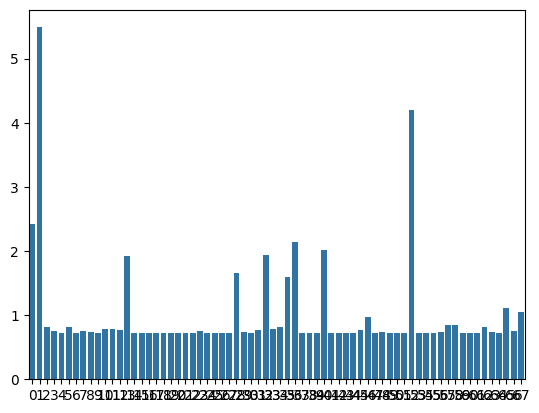

In [5]:
feature_weights = compute_feature_weights_with_temperature(0.01, -feature_importance_cv)
sns.barplot(feature_weights * len(feature_weights))

In [6]:
seed = 5
max_features = "sqrt"
auroc_method = train_feature_weighted_random_forest
sample_weights = np.ones(len(N)) / len(N)
n_estimators=1000

feature_weights_list = []
# budgets = [None, 0.1, 0.01, 0.005, 0.001]
budgets = [None, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]
for budget in budgets:
    feature_weights = compute_feature_weights_with_temperature(budget, -feature_importance_cv)
    feature_weights_list.append(feature_weights)

In [7]:
#for i, budget in enumerate(budgets):
#   auroc = compute_test_metrics_fw_mrs(
#       dropped_N,
#       R,
#       columns,
#       random_state=seed,
#       feature_weights=feature_weights_list[i],
#       method=auroc_method,
#       class_weight="balanced",
#       max_features="sqrt",
#       splitter="feature_weighted_best",
#       n_splits_test=5,
#       n_estimators=100,
#       draw_with_feature_weights=True,
#   )
#   print(f"{budget}: {auroc}")

None: 0.6039460683178859\
0.02: 0.5912344888376883\
0.05: 0.5493763819797175\
0.1: 0.5242090747237785

In [8]:
for i,budget in enumerate(budgets):
        auroc, auprc = compute_classification_metrics_gradient_descent(
                N,
                R,
                R,
                columns,
                sample_weights,
                feature_weights_list[i],
                target,
                random_state=seed,
                n_splits=5,
        )
        print(f"{budget} Auroc: {auroc}")
        print(f"{budget} AUPRC: {auprc}\n")

{'lambda_value': 0.05, 'learning_rate': 0.01, 'regularization_name': 'l2'}
None Auroc: 0.8652534518071102
None AUPRC: 0.826031072998942

{'lambda_value': 0.05, 'learning_rate': 0.01, 'regularization_name': 'l2'}
0.5 Auroc: 0.8652562690338885
0.5 AUPRC: 0.8260350591762458

{'lambda_value': 0.1, 'learning_rate': 0.01, 'regularization_name': 'l2'}
0.1 Auroc: 0.8652140106322137
0.1 AUPRC: 0.826000436604985

{'lambda_value': 0.01, 'learning_rate': 0.01, 'regularization_name': 'l2'}
0.05 Auroc: 0.8652872585284497
0.05 AUPRC: 0.8261035224123974

{'lambda_value': 0.05, 'learning_rate': 0.01, 'regularization_name': 'l2'}
0.01 Auroc: 0.8650337081184023
0.01 AUPRC: 0.82573464983494

{'lambda_value': 0.001, 'learning_rate': 0.01, 'regularization_name': 'l1'}
0.005 Auroc: 0.8652111934054355
0.005 AUPRC: 0.8259848427428809

{'lambda_value': 0.001, 'learning_rate': 0.01, 'regularization_name': 'l1'}
0.001 Auroc: 0.8650646976129637
0.001 AUPRC: 0.8258343945310527



In [9]:
for i,budget in enumerate(budgets):
    feature_weights = feature_weights_list[i]
    auroc, auprc = compute_classification_metrics_random_forest(
            N,
            R,
            R,
            columns,
            sample_weights,
            feature_weights,
            target,
            random_state=seed,
            n_splits=5,
            splitter="feature_weighted_best",
            n_estimators=500,
            draw_with_feature_weights=True,
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

None Auroc: 0.8596809772396249
None AUPRC: 0.8190394606891873

0.5 Auroc: 0.8591682419659735
0.5 AUPRC: 0.8190451666540142

0.1 Auroc: 0.8625207418321552
0.1 AUPRC: 0.8222161753447094

0.05 Auroc: 0.8614473784296214
0.05 AUPRC: 0.8210506651279537

0.01 Auroc: 0.8546747652545787
0.01 AUPRC: 0.8094321386922013

0.005 Auroc: 0.844169326598283
0.005 AUPRC: 0.7876487623483133

0.001 Auroc: 0.8374446062784715
0.001 AUPRC: 0.7782867639484223



In [10]:
def smoothly_clipped_absolute_deviation(coefficients, lambda_value=0.4, a=3.7):
        gradients = np.zeros(len(coefficients))
        first_indices = np.abs(coefficients) <= lambda_value
        if first_indices.any():
            gradients[first_indices] = lambda_value * np.sign(coefficients[first_indices])

        second_indices = (lambda_value < np.abs(coefficients)) & (
            np.abs(coefficients) <= a * lambda_value
        )
        if second_indices.any():
            gradients[second_indices] = (
                (a * lambda_value - np.abs(coefficients[second_indices]))
                * np.sign(coefficients[second_indices])
            ) / (a - 1)

        return gradients

<Axes: >

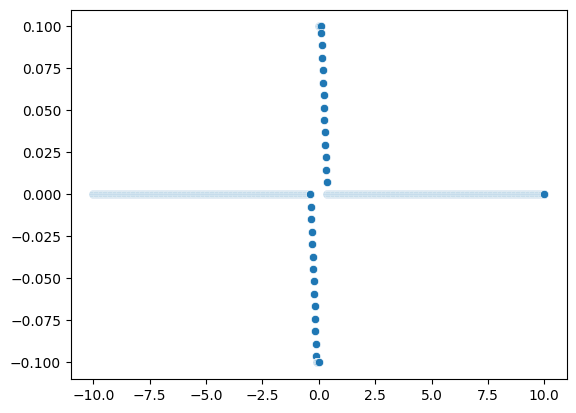

In [11]:
x= np.linspace(-10, 10, 1000)
y = smoothly_clipped_absolute_deviation(x, lambda_value=0.1)
sns.scatterplot(x=x, y=y)